In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
# Load Microsoft stock data from a CSV file into a pandas DataFrame
# Load Microsoft stock data from a CSV file into a pandas DataFrame
# pd.read_csv() reads the file and converts it into a table-like structure

# '../data/microsoft.csv' → file path to the dataset
# index_col='Date' → sets the Date column as the index (useful for time series analysis)

ms = pd.read_csv('data/microsoft.csv', index_col='Date')

# Display the first 5 rows of the dataset
ms.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500
2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900
2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900
2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900
2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100


In [ ]:
# Estimate the average stock return with 90% Confidence Interval

In [4]:
# Compute log returns for Microsoft stock

# shift(-1): next day price
# log(): natural logarithm
# difference gives log return
ms['logReturn'] = np.log(ms['Close'].shift(-1)) - np.log(ms['Close'])

In [5]:
# 90% confidence interval for mean log return

# number of observations
sample_size = ms['logReturn'].shape[0]

# sample mean of log returns
sample_mean = ms['logReturn'].mean()

# standard error of the mean
sample_std = ms['logReturn'].std(ddof=1) / sample_size**0.5


# z-scores for 90% CI
z_left = norm.ppf(0.05)
z_right = norm.ppf(0.95)


# confidence interval bounds
interval_left = sample_mean + z_left * sample_std
interval_right = sample_mean + z_right * sample_std

In [6]:
# Display the 90% confidence interval for mean log return

# interval_left: lower bound
# interval_right: upper bound
print('90% confidence interval is ', (interval_left, interval_right))

90% confidence interval is  (np.float64(-1.560325389937862e-05), np.float64(0.001656066226145423))


In [ ]:
# Hypothesis Testing

In [8]:
# Load Microsoft stock data

# read CSV and set Date as index
ms = pd.read_csv('data/microsoft.csv', index_col='Date')

# create log returns column
# shift(-1): next day price
# log difference = return
ms['logReturn'] = np.log(ms['Close'].shift(-1)) - np.log(ms['Close'])

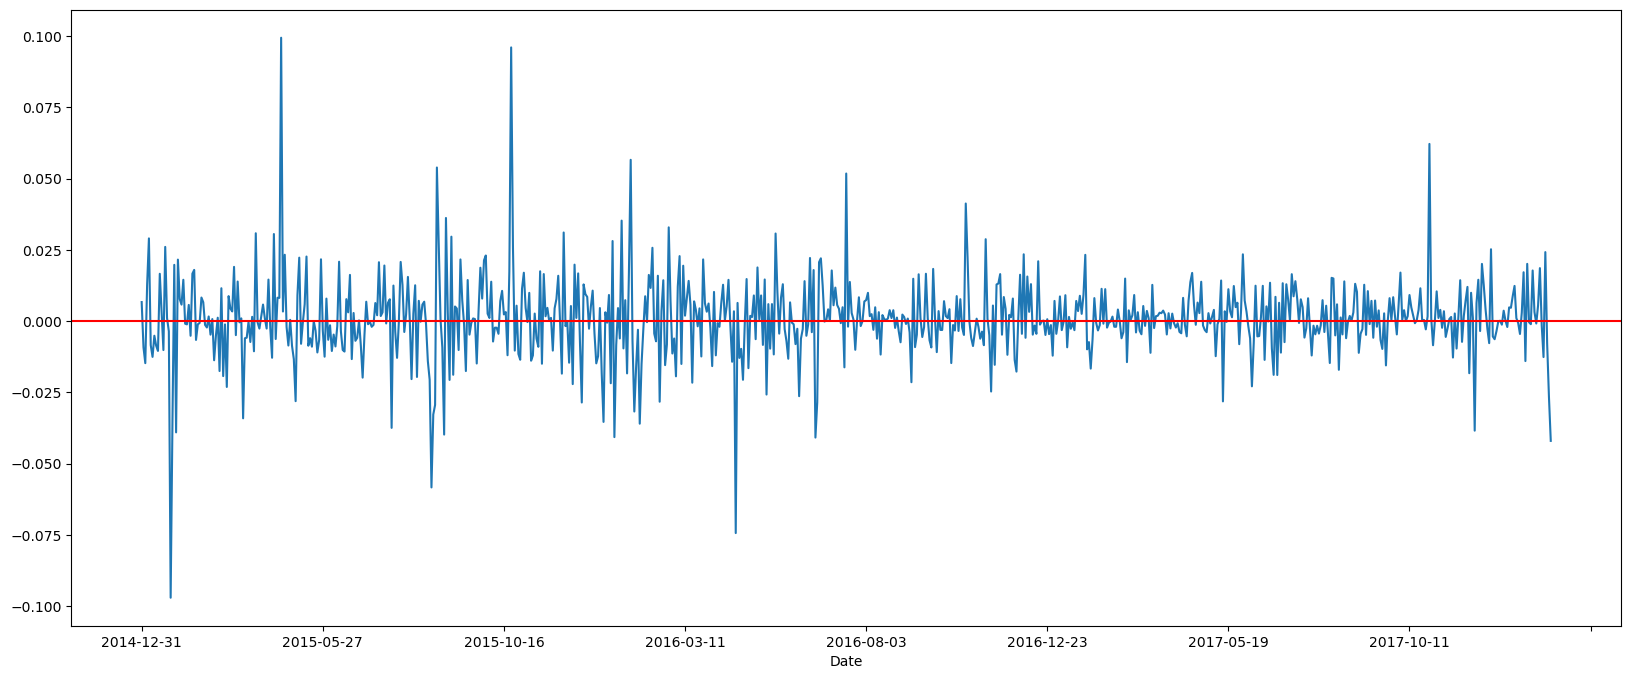

In [9]:
# Log return goes up and down during the period
ms['logReturn'].plot(figsize=(20, 8))
plt.axhline(0, color='red')
plt.show()

In [ ]:
# Steps involved in testing a claim by hypothesis testing

In [ ]:
# Step 1: Set hypothesis
# Hypothesis testing setup for mean log return

# H0 (null hypothesis): average return is 0
# Ha (alternative hypothesis): average return is not 0 (two-sided test)

# H0: μ = 0
# H1: μ ≠ 0

In [10]:
# Step 2: Calculate test statistic
# Compute z-statistic for hypothesis test on mean log return

# sample mean of log returns
sample_mean = ms['logReturn'].mean()

# sample standard deviation of log returns
sample_std = ms['logReturn'].std(ddof=1)

# number of observations
n = ms['logReturn'].shape[0]

# z-statistic formula under H0: mu = 0
# standard error = sample_std / sqrt(n)
zhat = (sample_mean - 0) / (sample_std / n**0.5)

# print z-score
print(zhat)

1.6141477140003675


In [11]:
# Step 3: Set desicion criteria
# Significance level (alpha)
alpha = 0.05

# Critical values for two-tailed test
# alpha/2 splits rejection region into two tails
zleft = norm.ppf(alpha/2, 0, 1)

# symmetry of normal distribution
zright = -zleft

# print critical z-values
print(zleft, zright)

-1.9599639845400545 1.9599639845400545


In [12]:
# Step 4:  Make decision - shall we reject H0?
# Decision rule for hypothesis test

# alpha: significance level
# zhat: computed test statistic
# zleft, zright: critical values

# If zhat is outside the range [zleft, zright], reject H0
print('At significant level of {}, shall we reject: {}'.format(
    alpha,
    (zhat > zright) or (zhat < zleft)
))

At significant level of 0.05, shall we reject: False


In [ ]:
# Try one tail test by yourself ! 
# $H_0 : \mu \leq 0$ 
# $H_a : \mu > 0$

In [13]:
# Step 2: compute z-statistic for hypothesis test

# sample mean of log returns
sample_mean = ms['logReturn'].mean()

# sample standard deviation
sample_std = ms['logReturn'].std(ddof=1)

# number of observations
n = ms['logReturn'].shape[0]

# z-test statistic (H0: mu = 0)
# standard error = sample_std / sqrt(n)
zhat = (sample_mean - 0) / (sample_std / n**0.5)

# print z-statistic
print(zhat)

1.6141477140003675


In [14]:
# Step 3: critical value for one-sided test

# significance level
alpha = 0.05

# right-tail critical z value
# 1 - alpha gives upper 5% cutoff
zright = norm.ppf(1 - alpha, 0, 1)

# print critical value
print(zright)

1.6448536269514722


In [15]:
# Step 4: decision rule for hypothesis test

# alpha: significance level
# zhat: computed test statistic
# zright: critical value for rejection region

# reject H0 if test statistic is greater than critical value
print('At significant level of {}, shall we reject: {}'.format(
    alpha,
    zhat > zright
))

At significant level of 0.05, shall we reject: False


In [ ]:
# An alternative method: p-value

In [16]:
# Step 3: compute p-value for the z-test

# p-value = probability of observing a value as extreme or more extreme than zhat
# since this is a right-tailed test, we take 1 - CDF

p = 1 - norm.cdf(zhat, 0, 1)

# print p-value
print(p)

0.053247694996968464


In [17]:
# Step 4: decision rule using p-value approach

# alpha: significance level
# p: computed p-value

# reject H0 if p-value is less than alpha
print('At significant level of {}, shall we reject: {}'.format(
    alpha,
    p < alpha
))

At significant level of 0.05, shall we reject: False


In [ ]:
# Population and Sample

In [18]:
# Create a small population dataset (10 values)

# empty DataFrame
data = pd.DataFrame()

# population values
# this represents the full population we will sample from
data['Population'] = [47, 48, 85, 20, 19, 13, 72, 16, 50, 60]

In [19]:
# Draw a random sample of size 5 from the population
# replace=True means values can be picked more than once

a_sample_with_replacement = data['Population'].sample(5, replace=True)

# print sampled values
print(a_sample_with_replacement)

4    19
6    72
2    85
3    20
8    50
Name: Population, dtype: int64


In [20]:
# Draw a random sample of size 5 from the population
# replace=False means each value can only be picked once

a_sample_without_replacement = data['Population'].sample(5, replace=False)

# print sampled values
print(a_sample_without_replacement)

0    47
5    13
4    19
9    60
8    50
Name: Population, dtype: int64


In [ ]:
# Parameters and Statistics

In [21]:
# Compute population mean and variance

# mean of all values in the population
population_mean = data['Population'].mean()

# variance of population (ddof=0 → population variance)
population_var = data['Population'].var(ddof=0)

# print results
print('Population mean is ', population_mean)
print('Population variance is', population_var)

Population mean is  43.0
Population variance is 571.8


In [22]:
# Draw a random sample of size 10 (with replacement)
# replace=True means values can repeat

a_sample = data['Population'].sample(10, replace=True)

# compute sample mean
sample_mean = a_sample.mean()

# compute sample variance
# var() uses ddof=1 by default → sample variance
sample_var = a_sample.var()

# print results
print('Sample mean is ', sample_mean)
print('Sample variance is', sample_var)

Sample mean is  41.3
Sample variance is 522.9000000000001


In [ ]:
# Average of an unbiased estimator

In [23]:
# Number of repeated samples
sample_length = 500

# Collect sample variances from 500 random samples
# each sample has size 10 drawn with replacement
# var(ddof=1) gives sample variance (not population variance)
sample_variance_collection = [
    data['Population'].sample(10, replace=True).var(ddof=1)
    for i in range(sample_length)
]

In [ ]:
# Variation of Sample

In [24]:
# Generate a random sample from a normal distribution
# mean = 10, standard deviation = 5, sample size = 30

Fstsample = pd.DataFrame(np.random.normal(10, 5, size=30))

# compute sample mean
print('sample mean is ', Fstsample[0].mean())

# compute sample standard deviation (ddof=1 → sample SD)
print('sample SD is ', Fstsample[0].std(ddof=1))

sample mean is  8.76831267008455
sample SD is  5.355193894945808


In [ ]:
# Empirical Distribution of mean

In [25]:
# Store sample means
# We will simulate 10,000 samples and record their means

meanlist = []

# repeat experiment 10,000 times
for t in range(10000):
    
    # draw a sample of size 30 from N(10, 5)
    sample = pd.DataFrame(np.random.normal(10, 5, size=30))
    
    # compute mean of this sample and store it
    meanlist.append(sample[0].mean())

In [26]:
# Convert list of sample means into a DataFrame
# This makes it easier to analyze and plot the distribution

collection = pd.DataFrame()

# store all sample means in a single column
collection['meanlist'] = meanlist

<Axes: >

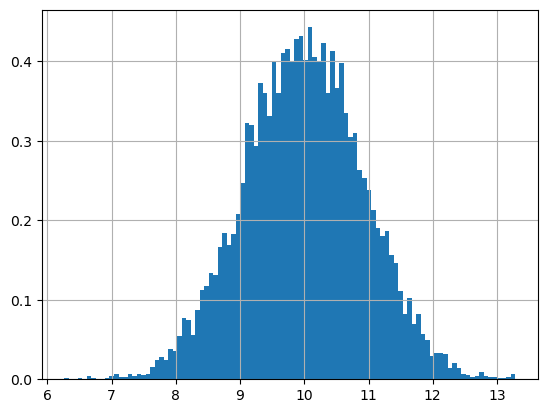

In [27]:
# Plot histogram of sample means

collection['meanlist'].hist(bins=100, density=1)

In [ ]:
#Sampling from Arbritary Distribution

array([[<Axes: title={'center': 'meanlist'}>]], dtype=object)

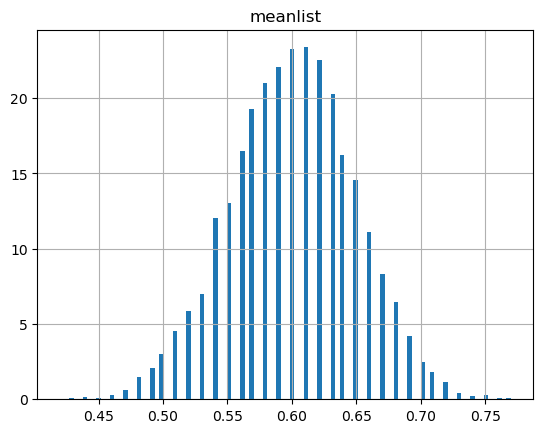

In [28]:
# Central Limit Theorem (CLT) demonstration
# As sample size increases, distribution of sample means becomes approximately normal

# sample size from a non-normal population
sample_size = 100

# store sample means
samplemeanlist = []

# population (not normal: only 0s and 1s)
apop = pd.DataFrame([1, 0, 1, 0, 1])

# repeat sampling 10,000 times
for t in range(10000):
    
    # draw sample with replacement
    sample = apop[0].sample(sample_size, replace=True)
    
    # store sample mean
    samplemeanlist.append(sample.mean())

# collect results into DataFrame
acollec = pd.DataFrame()
acollec['meanlist'] = samplemeanlist

# plot distribution of sample means
acollec.hist(bins=100, density=1)